# 03 · Real satellite data: decoding a SatNOGS pass
**Track 1 · Deep-Space Link Agent: README Part 3**

The other notebooks use simulated signals. Here the receiver runs on a **real recording** from a SatNOGS ground station
and decodes the satellite's telemetry packets, then checks them against what SatNOGS itself decoded.

```
SatNOGS audio (.ogg) ─► auto-tune tones ─► band-pass ─► mark/space discriminator ─► bit clock (DPLL)
                     ─► NRZI ─► HDLC frames ─► CRC-16 ─► AX.25 packets ─► compare with SatNOGS
```

**Decoder supports:** AFSK 1200 baud (Bell 202) with AX.25, the most common amateur-satellite packet mode.

### How to get a recording
1. Go to https://network.satnogs.org → **Observations → Browse**.
2. Pick an observation that is marked **good**, has **audio** and **decoded data**, and whose transmitter mode is
   **AFSK 1k2** (AFSK 1200). The ISS APRS digipeater (145.825 MHz) is a common one; many cubesats use it too.
   Other modes (GMSK 9600, BPSK, CW) won't decode with this decoder.
3. Download the observation's **audio file** (`.ogg`) into `data/satnogs/`.
4. Optional, for comparison: open the observation's **Data** tab and save the decoded frames (the hex lines) as a
   `.txt` file in `data/satnogs/`.
5. Set the paths below and **Run All**. With no file set, the notebook runs on a synthetic stand-in so you can test it.

IQ recordings are only occasionally available; this notebook works from the audio, which every observation has.

Reading `.ogg` needs `pip install soundfile` (or ffmpeg installed).

## 0. Settings

In [62]:
AUDIO_PATH     = "data/satnogs/Audio_OrigamiSat2.ogg"
REFERENCE_PATH = None
BAUD           = 1200

In [63]:
import importlib, src.afsk, src.satnogs
importlib.reload(src.afsk)
importlib.reload(src.satnogs)
print(src.satnogs.__file__)
print("NEW version" if "n_bursts" in open(src.satnogs.__file__).read() else "OLD version")
from src.satnogs import plot_results, load_audio, load_reference_frames, compare_with_reference, make_test_pass
from src.afsk import decode_afsk

/home/vinhvu/Deep_space_link/src/satnogs.py
NEW version


In [64]:
# !pip install numpy scipy matplotlib pandas soundfile
import os, sys, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.getcwd())
from src.afsk import decode_afsk
from src.satnogs import load_audio, load_reference_frames, compare_with_reference, make_test_pass, plot_results

%matplotlib inline
plt.rcParams["figure.dpi"] = 110
os.makedirs("results", exist_ok=True)

T_START = time.time()
def step(title):
    print(f"\n{'=' * 72}\n[{time.strftime('%H:%M:%S')}] (+{time.time() - T_START:7.1f} s)  {title}\n{'=' * 72}")
def info(msg):
    print(f"   [{time.strftime('%H:%M:%S')}] {msg}")

step("STEP 0  Setup")
DEMO = AUDIO_PATH is None
if DEMO:
    os.makedirs("data/satnogs", exist_ok=True)
    AUDIO_PATH, REFERENCE_PATH = "data/satnogs/demo_pass.wav", "data/satnogs/demo_reference.txt"
    n = make_test_pass(AUDIO_PATH, REFERENCE_PATH)
    info(f"DEMO MODE: no file set, generated a synthetic {n}-packet test pass (NOT real satellite data)")
else:
    info(f"real recording: {AUDIO_PATH}")


[14:14:26] (+    0.0 s)  STEP 0  Setup
   [14:14:26] real recording: data/satnogs/Audio_OrigamiSat2.ogg


## 1. Load the recording

In [65]:
step("STEP 1  Load audio")
t0 = time.time()
x, fs = load_audio(AUDIO_PATH)
info(f"{len(x)/fs:.1f} s of audio at {fs} Hz ({len(x)} samples), loaded in {time.time()-t0:.1f} s")
info(f"peak level {np.abs(x).max():.3f}, RMS {np.sqrt(np.mean(x**2)):.3f}")


[14:14:27] (+    0.6 s)  STEP 1  Load audio
   [14:14:32] 355.4 s of audio at 48000 Hz (17056952 samples), loaded in 5.6 s
   [14:14:32] peak level 2.628, RMS 0.307


**Listen to it.** APRS packets sound like short buzzy screeches (about 0.3 to 1 s each). If you hear only steady
hiss for the whole recording, there are probably no packets in it.

In [66]:
from IPython.display import Audio
Audio(x[:int(60 * fs)], rate=fs)      # first 60 seconds

## 2. Decode
The decoder tunes itself: it measures where the two tones actually are (mistuning shifts them), measures their level
difference (FM pre-emphasis), and runs several slicers with different balances, keeping every frame that passes CRC.

In [67]:
step("STEP 2  Decode AFSK / AX.25")
t0 = time.time()
frames, diag = decode_afsk(x, fs, baud=BAUD, log=info)
info(f"decoded {len(frames)} unique AX.25 frames with valid CRC in {time.time()-t0:.1f} s")


[14:14:33] (+    6.7 s)  STEP 2  Decode AFSK / AX.25
   [14:14:34] WARNING: no clear AFSK tone pair above the noise, using nominal 1200/2200 Hz. The recording may contain no packets.
   [14:14:54] signal present in 0.0% of the recording
   [14:14:54] measured tone balance (twist) +1.0 dB, running 5 slicers
   [14:14:55]   slicer balance x0.5 :   0 valid frames (0 new)
   [14:14:56]   slicer balance x0.7 :  79 valid frames (70 new)
   [14:14:57]   slicer balance x1.0 :  38 valid frames (1 new)
   [14:14:59]   slicer balance x1.4 :   0 valid frames (0 new)
   [14:15:00]   slicer balance x2.0 :   0 valid frames (0 new)
   [14:15:00] decoded 71 unique AX.25 frames with valid CRC in 26.8 s


## 3. Decoded packets (telemetry log)

In [68]:
step("STEP 3  Telemetry log")
log = pd.DataFrame(frames)
log.to_csv("results/satnogs_frames.csv", index=False)
info("saved results/satnogs_frames.csv")
if len(log):
    for _, f in log.iterrows():
        print(f"     t={f.time_s:7.2f}s  {f.summary[:110]}")
    info(f"senders: {log.src.value_counts().to_dict() if 'src' in log else '-'}")
else:
    info("no frames decoded: check the mode is AFSK 1200 and the observation has visible signal in the waterfall")
log.drop(columns=["hex"], errors="ignore").head(20)


[14:15:00] (+   33.5 s)  STEP 3  Telemetry log
   [14:15:00] saved results/satnogs_frames.csv
     t=  53.73s  JS1YRU>JS1YNU: cc fe 82 01 6a 71 a8 37 be 00 00 02 01 00 00 00 0b 5c 01 01 01 00 41 42 c6 d6 d2 db bc 30 41 fc
     t=  55.78s  JS1YRU>JS1YNU: cc fe 82 02 6a 71 a8 46 fd 00 00 06 01 00 00 00 0b 5c 01 01 01 00 41 42 c7 24 6f 52 35 fd 41 df
     t=  57.63s  JS1YRU>JS1YNU: cc fe 82 03 6a 71 a8 7f fd 00 00 06 01 00 00 00 0b 5c 01 01 01 00 41 42 c7 24 6f 57 f9 c1 42 03
     t=  59.48s  JS1YRU>JS1YNU: cc fe 82 04 6a 71 a8 80 fd 00 00 06 01 00 00 00 0b 5c 01 01 01 00 41 42 c7 24 6f 5d 96 af 42 02
     t=  61.33s  JS1YRU>JS1YNU: cc fe 82 06 6a 71 a8 82 fd 00 00 06 01 00 00 00 0b 5c 01 01 01 00 41 42 c7 24 6f 68 f7 61 41 dc
     t=  63.18s  JS1YRU>JS1YNU: cc fe 82 07 6a 71 a8 91 fd 00 00 06 01 00 00 00 0b 5c 01 01 01 00 41 42 c7 24 6f 6e bb 25 41 f4
     t=  65.33s  JS1YRU>JS1YNU: cc fe 82 08 6a 71 a8 a0 fd 00 00 06 01 00 00 00 0b 5c 01 01 01 00 41 42 c7 24 6f 74 58 13 42 02
     t=  

,time_s,length,dest,src,path,control,pid,info_len,text,summary
0,53.728,223,JS1YNU,JS1YRU,,3,240,207,cc fe 82 01 6a 71 a8 37 be 00 00 02 01 00 00 0...,JS1YRU>JS1YNU: cc fe 82 01 6a 71 a8 37 be 00 0...
1,55.778,223,JS1YNU,JS1YRU,,3,240,207,cc fe 82 02 6a 71 a8 46 fd 00 00 06 01 00 00 0...,JS1YRU>JS1YNU: cc fe 82 02 6a 71 a8 46 fd 00 0...
2,57.628,223,JS1YNU,JS1YRU,,3,240,207,cc fe 82 03 6a 71 a8 7f fd 00 00 06 01 00 00 0...,JS1YRU>JS1YNU: cc fe 82 03 6a 71 a8 7f fd 00 0...
3,59.478,223,JS1YNU,JS1YRU,,3,240,207,cc fe 82 04 6a 71 a8 80 fd 00 00 06 01 00 00 0...,JS1YRU>JS1YNU: cc fe 82 04 6a 71 a8 80 fd 00 0...
4,61.333,223,JS1YNU,JS1YRU,,3,240,207,cc fe 82 06 6a 71 a8 82 fd 00 00 06 01 00 00 0...,JS1YRU>JS1YNU: cc fe 82 06 6a 71 a8 82 fd 00 0...
5,63.178,223,JS1YNU,JS1YRU,,3,240,207,cc fe 82 07 6a 71 a8 91 fd 00 00 06 01 00 00 0...,JS1YRU>JS1YNU: cc fe 82 07 6a 71 a8 91 fd 00 0...
6,65.328,223,JS1YNU,JS1YRU,,3,240,207,cc fe 82 08 6a 71 a8 a0 fd 00 00 06 01 00 00 0...,JS1YRU>JS1YNU: cc fe 82 08 6a 71 a8 a0 fd 00 0...
7,67.178,223,JS1YNU,JS1YRU,,3,240,207,cc fe 82 09 6a 71 a8 af fd 00 00 06 01 00 00 0...,JS1YRU>JS1YNU: cc fe 82 09 6a 71 a8 af fd 00 0...
8,69.028,223,JS1YNU,JS1YRU,,3,240,207,cc fe 82 0a 6a 71 a8 be fd 00 00 06 01 00 00 0...,JS1YRU>JS1YNU: cc fe 82 0a 6a 71 a8 be fd 00 0...
9,70.878,223,JS1YNU,JS1YRU,,3,240,207,cc fe 82 0b 6a 71 a8 cd fd 00 00 06 01 00 00 0...,JS1YRU>JS1YNU: cc fe 82 0b 6a 71 a8 cd fd 00 0...


## 4. Before / after plots


[14:15:00] (+   33.8 s)  STEP 4  Plots


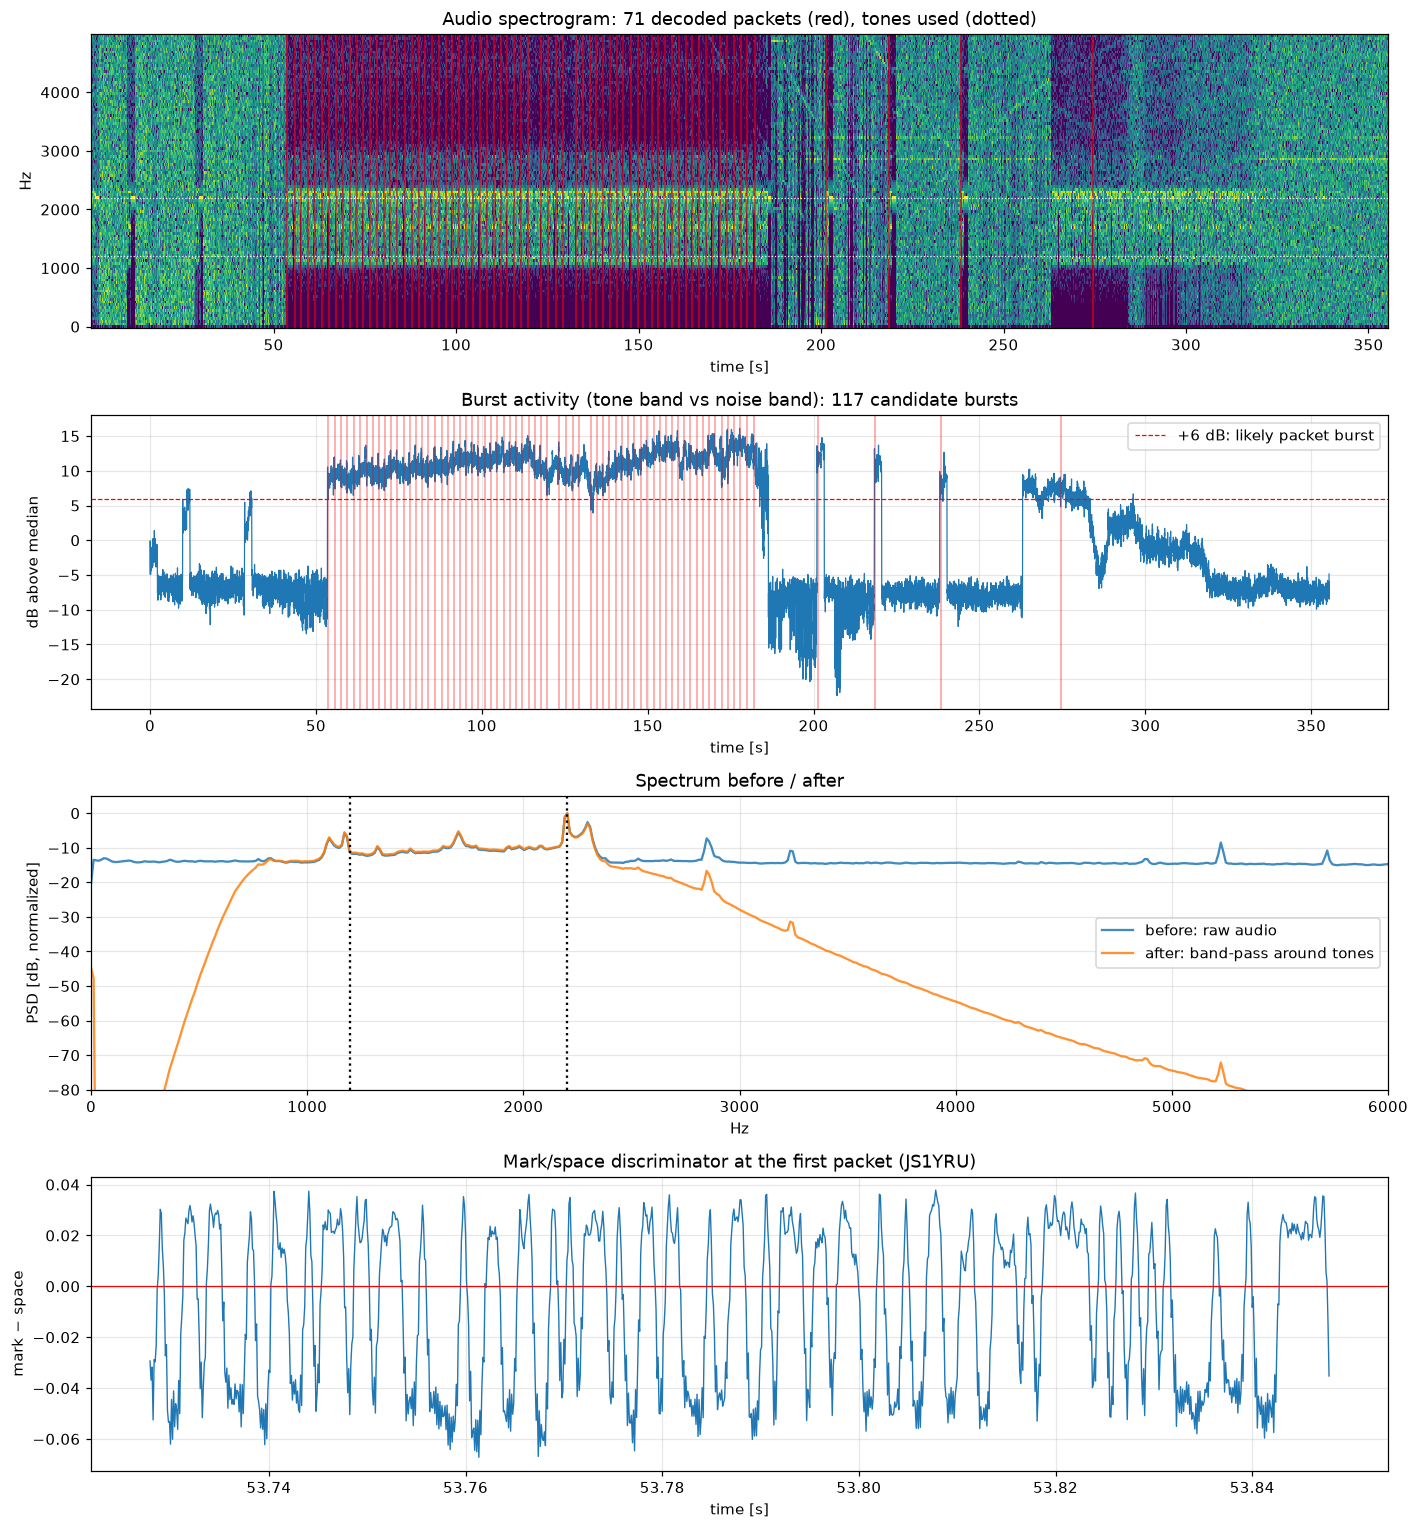

   [14:15:21] candidate packet bursts seen in the audio: 117
   [14:15:21] saved results/satnogs_overview.png


In [69]:
step("STEP 4  Plots")
_, n_bursts = plot_results(x, fs, frames, diag, out_prefix="results/satnogs")
plt.show()
info(f"candidate packet bursts seen in the audio: {n_bursts}")
if len(frames) == 0 and n_bursts == 0:
    info("no bursts and no frames: this recording most likely has no AFSK packets. Try another observation "
         "(one with decoded data in SatNOGS) and check its waterfall first.")
elif len(frames) == 0:
    info("bursts seen but nothing decoded: send the plot and the Step 2 log for tuning.")
info("saved results/satnogs_overview.png")

## 5. Compare with SatNOGS' own decoder
Frames we decoded that SatNOGS also decoded are an independent check that our receiver is right.
Frames only we decoded show where our decoder is more sensitive.

In [70]:
step("STEP 5  Compare with SatNOGS")
if REFERENCE_PATH and os.path.exists(REFERENCE_PATH):
    ref = load_reference_frames(REFERENCE_PATH)
    c = compare_with_reference(frames, ref)
    info(f"SatNOGS listed {c['reference']} frames, we decoded {c['ours']}")
    info(f"we found {c['reference_found']}/{c['reference']} of SatNOGS' frames (missed {c['missed']})")
    info(f"frames only we decoded: {c['only_ours']}")
else:
    c = None
    info("no reference file set, skipped")


[14:15:21] (+   55.1 s)  STEP 5  Compare with SatNOGS
   [14:15:21] no reference file set, skipped


## 6. Summary

In [71]:
step("STEP 6  Summary")
rows = [("Recording", os.path.basename(AUDIO_PATH) + ("  (SYNTHETIC DEMO)" if DEMO else "")),
        ("Duration", f"{len(x)/fs:.1f} s at {fs} Hz"),
        ("Tones used", f"{diag['mark']:.0f} / {diag['space']:.0f} Hz" + ("" if diag["tones_found"] else "  (nominal: no clear tones found)")),
        ("Candidate packet bursts", str(n_bursts)),
        ("Frames decoded (CRC ok)", str(len(frames)))]
if c:
    rows.append(("Agreement with SatNOGS", f"{c['reference_found']}/{c['reference']} found, {c['only_ours']} extra"))
summary = pd.DataFrame(rows, columns=["metric", "value"])
summary.to_csv("results/satnogs_summary.csv", index=False)
info(f"ALL DONE in {time.time() - T_START:.0f} s")
summary


[14:15:21] (+   55.3 s)  STEP 6  Summary
   [14:15:21] ALL DONE in 55 s


,metric,value
0,Recording,Audio_OrigamiSat2.ogg
1,Duration,355.4 s at 48000 Hz
2,Tones used,1200 / 2200 Hz (nominal: no clear tones found)
3,Candidate packet bursts,117
4,Frames decoded (CRC ok),71


**Credits:** recordings from the SatNOGS Network (Libre Space Foundation), shared under CC BY-SA 4.0.
Cite the observation ID(s) you used in your README.